In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Wedge
from matplotlib.transforms import Affine2D
from scipy.stats import spearmanr, chi2_contingency, skew
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, normalized_mutual_info_score
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.tree import plot_tree
from joblib import Parallel, delayed

Pipeline de preparação do dataset PhiUSIIL: checagem e limpeza dos dados, remoção de colunas e seleção de features por redundância e relevância.

Ao final gerasse 3 csv para aplicação dos algoritmos:

df_1_posprocessamento.csv > csv processado sem os atributos não reproduziveis, fora do domínio e já mapeadas (-10 features da original)

df_2_red_1.csv > df_1_posprocessamento.csv menos feature com 100% de corr (-11 features da original)

df_3_red_2.csv > df_2_red_1.csv menos 10 features pouco correlaciodas em multimétodos com a label (-21 features da original)

A ideia seria testar o desempenho das três e utilizar a melhor, mas a df_3_red_2.csv ou uma ainda mais reduzida pode ser mais fácil para a aplicação.


O Dataset "PhiUSIIL_Phishing_URL_Dataset" possui 235795 registros de dados recolhidos 
de diversas raspagens, tendo o identificador Filename mostrando a qual arquio o registro pertence.

As features descrevem algumas das características e métricas das páginas, 
como identificadores, estrutura do link e das página web, além e análises de similaridade.

In [3]:
print("Features do dataset:")
print(df.columns)
print()

print("Verificação de nulos:")
print(df.isnull().sum())
print()

print("Verificação de registros duplicados:")
print(df.duplicated().sum())

Features do dataset:
Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       

Não houve necessidade de preenchimento de valores ausentes ou registros duplicados.

Seguimos para a analise dos tipos de features para a normalização e busca de outliers

In [ ]:

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Atributos Numéricos: {len(num_cols)}")
print(f"Atributos Categóricos: {len(cat_cols)}")
print('--------')

card = df.nunique().sort_values()
print("Atributos e quantidade de valores unicos:")
display(card)

print("Métricas das Variáveis Numéricas:")
display(df[num_cols].describe())

print("Métricas das Variáveis Categóricas:")
display(df[cat_cols].describe())

Atributos Numéricos: 51
Atributos Categóricos: 5
--------
Atributos e quantidade de valores unicos:


label                              2
HasTitle                           2
HasFavicon                         2
Robots                             2
IsResponsive                       2
NoOfURLRedirect                    2
NoOfSelfRedirect                   2
IsHTTPS                            2
HasDescription                     2
HasSocialNet                       2
HasSubmitButton                    2
HasHiddenFields                    2
HasPasswordField                   2
Bank                               2
Pay                                2
HasExternalFormSubmit              2
Crypto                             2
HasCopyrightInfo                   2
IsDomainIP                         2
HasObfuscation                     2
NoOfQMarkInURL                     5
NoOfSubDomain                     10
TLDLength                         12
NoOfObfuscatedChar                20
NoOfEqualsInURL                   25
NoOfAmpersandInURL                31
NoOfOtherSpecialCharsInURL        74
D

Métricas das Variáveis Numéricas:


,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


Métricas das Variáveis Categóricas:


,FILENAME,URL,Domain,TLD,Title
count,235795,235795,235795,235795,235795
unique,235795,235370,220086,695,197874
top,521848.txt,https://att-104164.weeblysite.com/,ipfs.io,com,0
freq,1,2,1197,112554,32719


As colunas Filename, URL, Domain, Title e TLD juntas na prática funcionam quase como o ID de página,
O que pode afetar a generalização do modelo. 
as colunas 'URLSimilarityIndex', 'TLDLegitimateProb', 'URLCharProb' não podem ser facilmente reproduzida,
dependendo muito da lista index usada

Além disso, metricas mais interessantes como a presença ou não e quantidade de caracteres dessas colunas 
já estão mapeadas no dataset

Segue a remoção das colunas mencionadas: 

In [ ]:
rem =['URL', 'Domain', 'Title', 'FILENAME', 'TLD','URLSimilarityIndex', 'TLDLegitimateProb', 'URLCharProb', 'DomainTitleMatchScore', 'URLTitleMatchScore']
df = df.drop(columns=rem, errors='ignore')
df.to_csv('df_1_posprocessamento.csv', index=False)
print("colunas shape1: ",df.shape)

def checar_e_reclassificar(df, label=None,
                           limiar_discreta_antigo=10,   
                           limiar_card_baixa=15,       
                           limiar_ratio_unique=0.05,  
                           pct_zeros_quase_bin=0.90):  
    cols = df.select_dtypes(include="number").columns.tolist()
    if label in cols:
        cols.remove(label)
    linhas = []
    for c in cols:
        s = df[c].dropna()
        nu = s.nunique()
        eh_inteira = bool(np.allclose(s.values, np.round(s.values)))
        ratio_u = nu / len(s)
        std = float(s.std())
        media = float(s.mean())
        cv = std / abs(media) if abs(media) > 1e-9 else np.nan          # coef. de variacao
        assimetria = float(skew(s)) if nu > 1 else 0.0
        pct_zeros = float((s == 0).mean())
        natureza = "binaria" if nu == 2 else ("contagem" if eh_inteira else "razao/score")
        antigo = ("binaria" if nu == 2
                  else "discreta" if nu <= limiar_discreta_antigo
                  else "continua")
        if nu == 2:
            sugerido = "binaria"
        elif eh_inteira and (nu <= limiar_card_baixa or ratio_u < limiar_ratio_unique):
            sugerido = "discreta"
        else:
            sugerido = "continua"
        quase_bin = (natureza == "contagem" and pct_zeros >= pct_zeros_quase_bin)
        linhas.append({
            "feature": c, "natureza": natureza, "inteira": eh_inteira,
            "n_unique": nu, "ratio_unique": round(ratio_u, 4),
            "min": round(float(s.min()), 3), "max": round(float(s.max()), 3),
            "std": round(std, 3), "cv": round(cv, 3) if pd.notna(cv) else np.nan,
            "assimetria": round(assimetria, 2), "pct_zeros": round(pct_zeros, 3),
            "tipo_antigo": antigo, "tipo_sugerido": sugerido,
            "mudou": antigo != sugerido, "quase_binaria": quase_bin,
        })
    tab = pd.DataFrame(linhas).sort_values(["tipo_sugerido", "n_unique"])
    pd.set_option("display.max_rows", None)
    pd.set_option("display.width", 170)
    print("checagem")
    print(tab.to_string(index=False), "\n")
    print(tab["natureza"].value_counts(), "\n")
    print("Resumo por tipo sugerido:")
    print(tab["tipo_sugerido"].value_counts(), "\n")
    mud = tab[tab["mudou"]]
    print(f"Colunas que MUDARIAM de tipo ({len(mud)}):")
    print(mud[["feature", "n_unique", "tipo_antigo", "tipo_sugerido"]].to_string(index=False)
          if len(mud) else "Nenhuma.", "\n")
    qb = tab[tab["quase_binaria"]]
    if len(qb):
        print(f"Candidatas a virar BINARIA (contagem com >= {int(pct_zeros_quase_bin*100)}% zeros):")
        print(qb[["feature", "pct_zeros", "max"]].to_string(index=False))
    tipos_novos = dict(zip(tab["feature"], tab["tipo_sugerido"]))
    return tab, tipos_novos


def aplicar_tipos(df):
    # Corrige o dtype de cada coluna numerica
    df = df.copy()
    for c in df.select_dtypes(include="number").columns:
        s = df[c].dropna()
        if len(s) == 0:
            continue
        eh_inteira = bool(np.allclose(s.values, np.round(s.values)))
        if eh_inteira:
            if df[c].isna().any():
                df[c] = df[c].round().astype("Int64")   
            else:
                df[c] = df[c].round().astype("int64")  
        else:
            df[c] = df[c].astype("float64")        
    return df

tabela, tipos_novos = checar_e_reclassificar(df, label="label")
df = aplicar_tipos(df)

print(df.dtypes, "\n")
print(df.head())

colunas shape1:  (235795, 46)
checagem
                   feature    natureza  inteira  n_unique  ratio_unique  min          max        std     cv  assimetria  pct_zeros tipo_antigo tipo_sugerido  mudou  quase_binaria
                IsDomainIP     binaria     True         2        0.0000  0.0        1.000      0.052 19.199       19.15      0.997     binaria       binaria  False          False
            HasObfuscation     binaria     True         2        0.0000  0.0        1.000      0.045 22.027       21.98      0.998     binaria       binaria  False          False
                   IsHTTPS     binaria     True         2        0.0000  0.0        1.000      0.412  0.527       -1.37      0.217     binaria       binaria  False          False
                  HasTitle     binaria     True         2        0.0000  0.0        1.000      0.346  0.401       -2.09      0.139     binaria       binaria  False          False
                HasFavicon     binaria     True         2        0

Para saber se existem outras colunas que possam ser reduntantes usamos correlação par a par de spearman, 
que considera a ordem dos valores, sendo a prova dos outliers.

O uso do MI ajuda a ver qual das duas se relaciona mais com a label


Tipos em uso: {'discreta': 20, 'binaria': 19, 'continua': 6} 



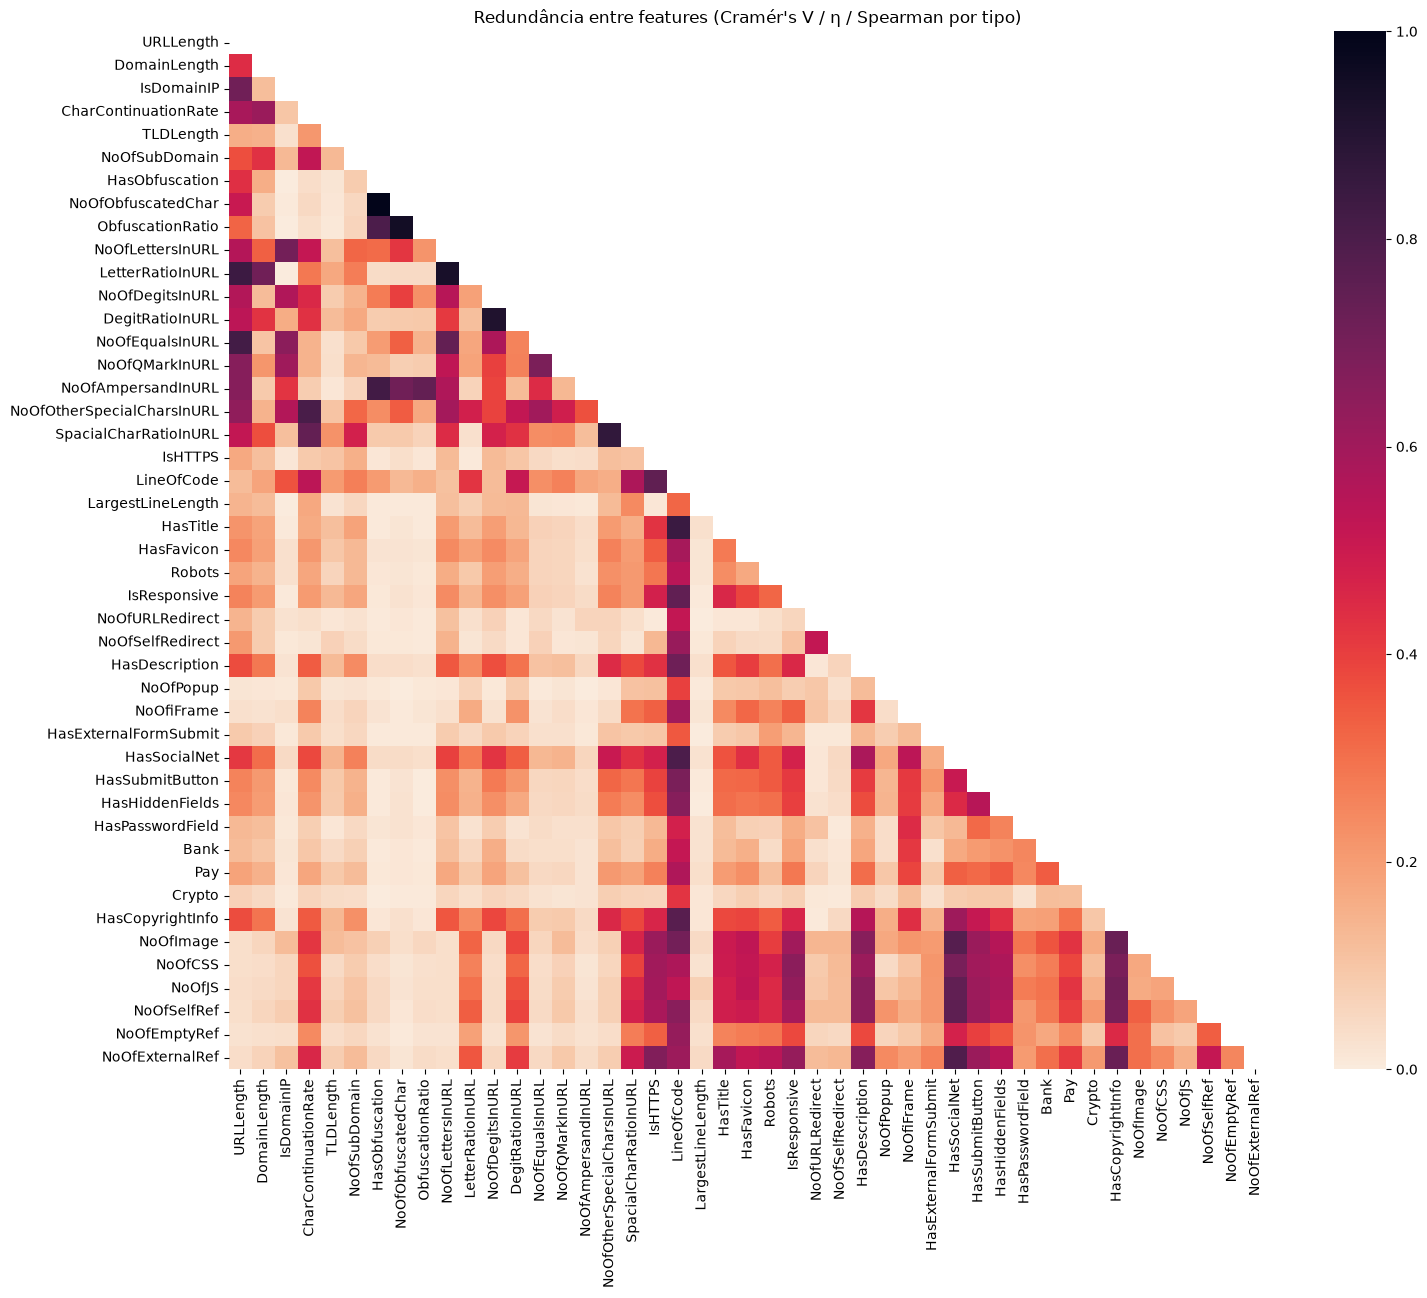

Pares com redundância >= 0.85 (mantém a de maior MI):

  HasObfuscation             x NoOfObfuscatedChar         1.000  ->  remove 'NoOfObfuscatedChar'
  NoOfObfuscatedChar         x ObfuscationRatio           0.951  ->  remove 'NoOfObfuscatedChar'
  NoOfLettersInURL           x LetterRatioInURL           0.934  ->  remove 'NoOfLettersInURL'
  NoOfDegitsInURL            x DegitRatioInURL            0.918  ->  remove 'NoOfDegitsInURL'
  NoOfOtherSpecialCharsInURL x SpacialCharRatioInURL      0.869  ->  remove 'SpacialCharRatioInURL'

Candidatas a remover (4): ['NoOfDegitsInURL', 'NoOfLettersInURL', 'NoOfObfuscatedChar', 'SpacialCharRatioInURL']

MI das candidatas:
NoOfObfuscatedChar       0.0017
NoOfLettersInURL         0.1552
NoOfDegitsInURL          0.1716
SpacialCharRatioInURL    0.2066


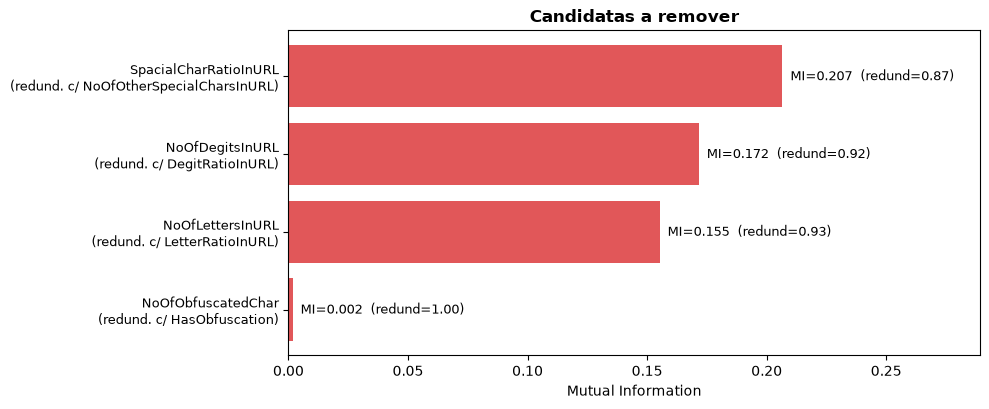

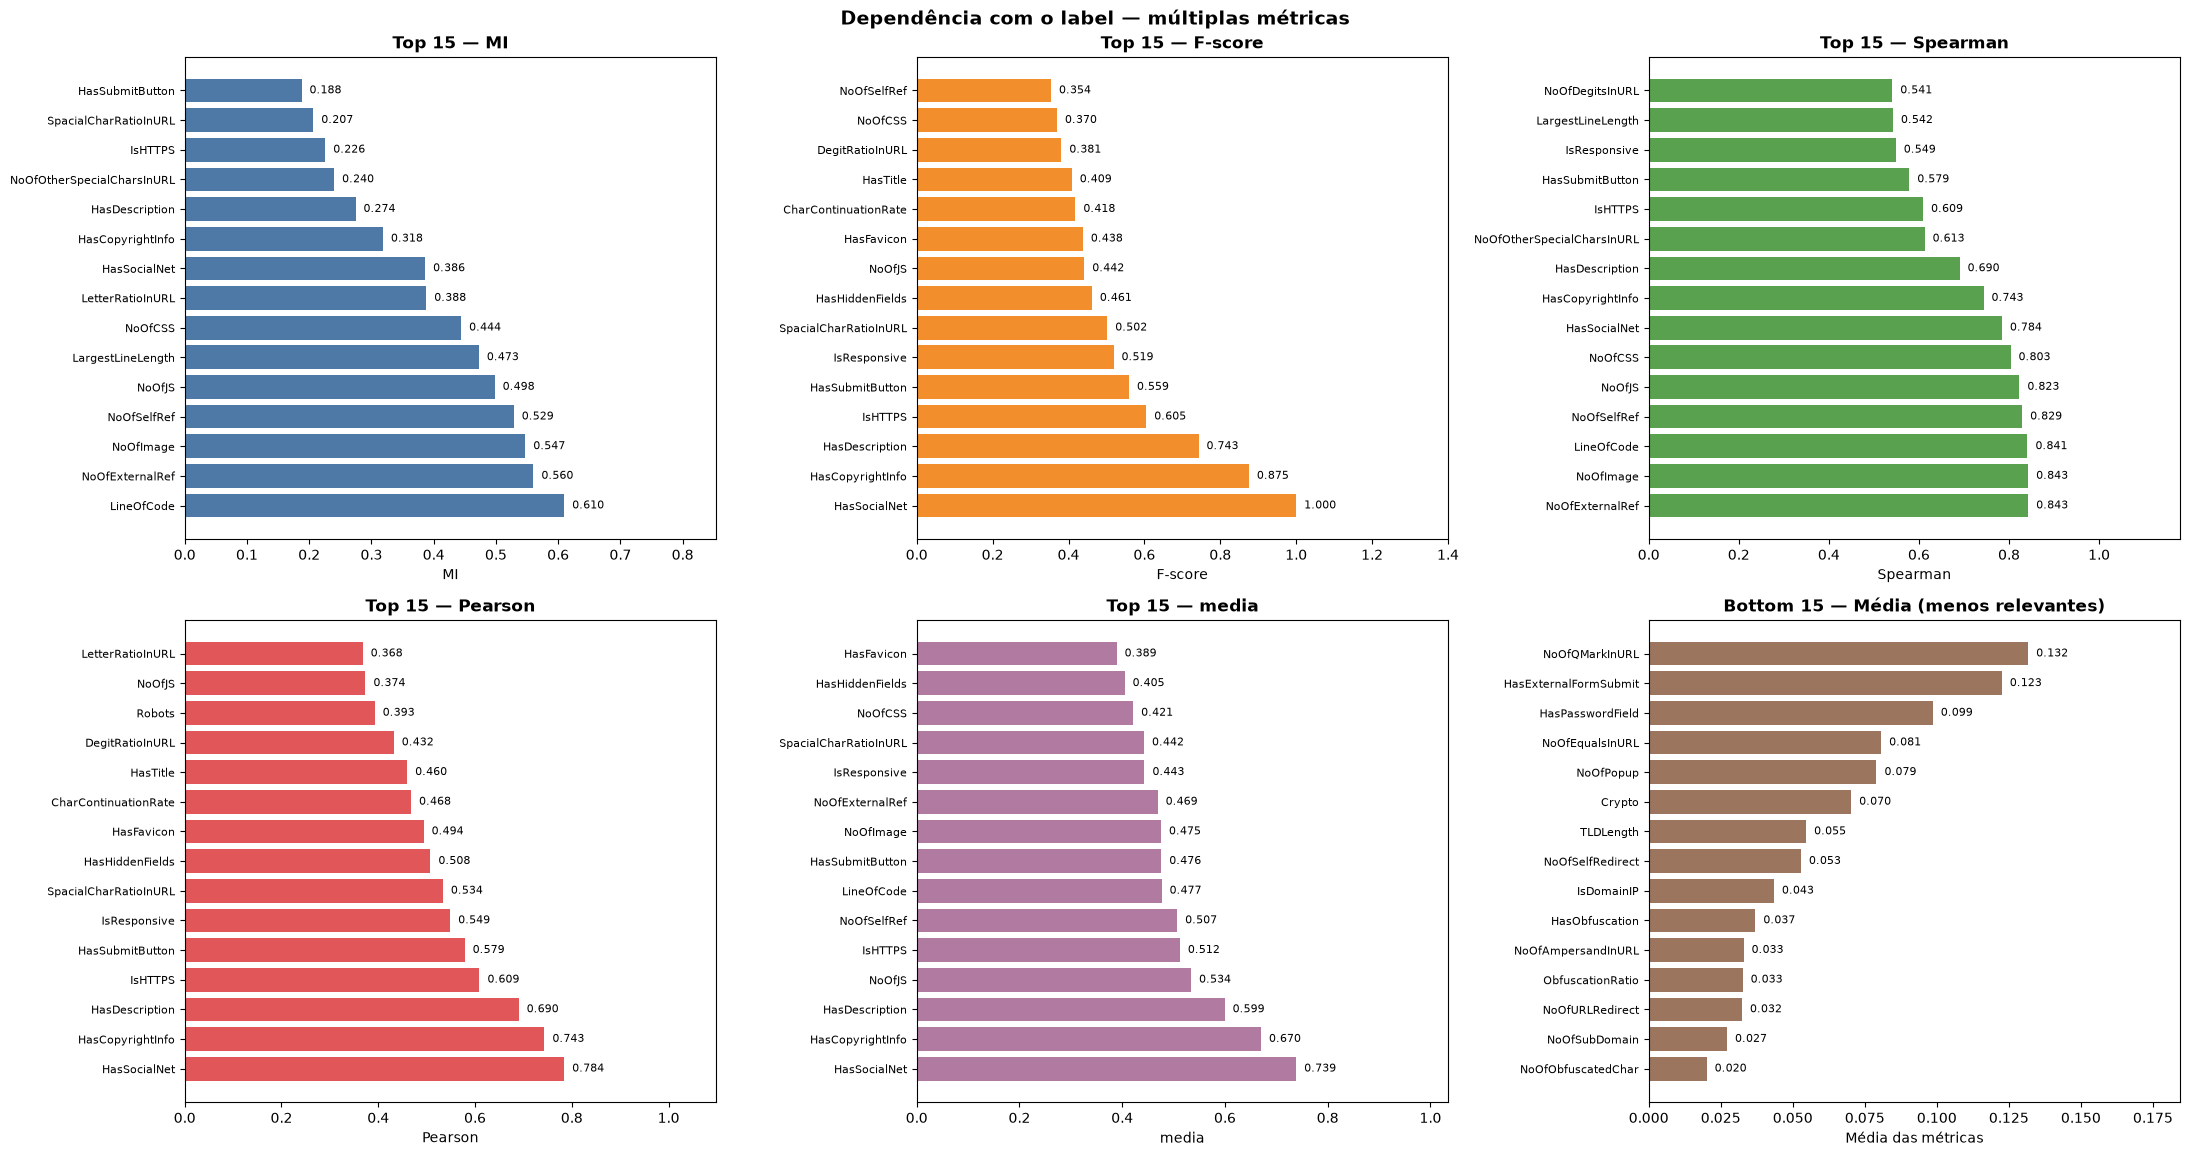

                                MI  F-score  Spearman  Pearson   media
HasSocialNet                0.3862   1.0000    0.7843   0.7843  0.7387
HasCopyrightInfo            0.3185   0.8753    0.7434   0.7434  0.6701
HasDescription              0.2744   0.7426    0.6902   0.6902  0.5994
NoOfJS                      0.4980   0.4415    0.8230   0.3735  0.5340
IsHTTPS                     0.2258   0.6048    0.6091   0.6091  0.5122
NoOfSelfRef                 0.5286   0.3539    0.8292   0.3162  0.5070
LineOfCode                  0.6097   0.1836    0.8410   0.2723  0.4766
HasSubmitButton             0.1876   0.5593    0.5786   0.5786  0.4760
NoOfImage                   0.5472   0.2375    0.8425   0.2747  0.4755
NoOfExternalRef             0.5602   0.2146    0.8426   0.2586  0.4690
IsResponsive                0.1572   0.5187    0.5486   0.5486  0.4433
SpacialCharRatioInURL       0.2066   0.5021    0.5274   0.5335  0.4424
NoOfCSS                     0.4441   0.3696    0.8034   0.0681  0.4213
HasHid

In [ ]:

def cramers_v(x, y):
    try:
        tab = pd.crosstab(x, y)
        if min(tab.shape) < 2:
            return 0.0
        chi2 = chi2_contingency(tab, correction=False)[0]
        n = tab.values.sum()
        return float(np.sqrt(chi2 / (n * (min(tab.shape) - 1))))
    except Exception:
        return np.nan

def correlation_ratio(cats, vals):
    try:
        cats = pd.Categorical(cats).codes
        vals = np.asarray(vals, dtype=float)
        media = vals.mean()
        num = sum(len(vals[cats == k]) * (vals[cats == k].mean() - media) ** 2
                  for k in np.unique(cats))
        den = ((vals - media) ** 2).sum()
        return float(np.sqrt(num / den)) if den > 0 else 0.0
    except Exception:
        return np.nan

def inferir_tipo(s, card_baixa=15, ratio_u=0.05):
    nu = s.nunique()
    if nu == 2:
        return "binaria"
    vals = s.dropna().values
    if np.allclose(vals, np.round(vals)) and (nu <= card_baixa or nu / len(s) < ratio_u):
        return "discreta"
    return "continua"

def _calc_par(i, j, cols, X_vals, tipos):
    cat = ("binaria", "discreta")
    ta, tb = tipos[cols[i]], tipos[cols[j]]
    if ta in cat and tb in cat:
        v = cramers_v(X_vals[:, i], X_vals[:, j])
    elif ta in cat:
        v = correlation_ratio(X_vals[:, i], X_vals[:, j])
    else:
        v = correlation_ratio(X_vals[:, j], X_vals[:, i])
    return i, j, 0.0 if (v is None or np.isnan(v)) else float(v)

def matriz_redundancia(X, tipos):
    cols = X.columns.tolist()
    n = len(cols)
    cat = ("binaria", "discreta")
    cont = [c for c in cols if tipos[c] == "continua"]
    M = np.eye(n)

    # bloco contínua × contínua p Spearman vetorizado (rápido)
    if len(cont) > 1:
        ci = [cols.index(c) for c in cont]
        sp = X[cont].corr(method="spearman").abs().values
        for ii, i in enumerate(ci):
            for jj, j in enumerate(ci):
                M[i, j] = sp[ii, jj]

    # pares com categóricas p paralelizado em threads
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)
              if not (tipos[cols[i]] == "continua" and tipos[cols[j]] == "continua")]
    X_vals = X.values
    for i, j, v in Parallel(n_jobs=-1, prefer="threads")(
        delayed(_calc_par)(i, j, cols, X_vals, tipos) for i, j in pairs
    ):
        M[i, j] = M[j, i] = v

    return pd.DataFrame(M, index=cols, columns=cols)

#  preparação
X = df.drop(columns=["label"], errors="ignore").select_dtypes("number").fillna(0)
y = df["label"]
X = X.loc[:, X.nunique() > 1]

try:
    tipos_novos
except NameError:
    tipos_novos = {}
tipos = {c: tipos_novos.get(c, inferir_tipo(X[c])) for c in X.columns}
print("Tipos em uso:", pd.Series(tipos).value_counts().to_dict(), "\n")

# heatmap de redundância 
corr = matriz_redundancia(X, tipos)
mask = np.triu(np.ones(corr.shape, dtype=bool))
plt.figure(figsize=(16, 13))
sns.heatmap(corr, mask=mask, cmap="rocket_r", vmin=0, vmax=1, square=True)
plt.title("Redundância entre features (Cramér's V / η / Spearman por tipo)")
plt.tight_layout(); plt.show()

# métricas de dependência com o label
amostra = X.sample(min(40_000, len(X)), random_state=42)
ya      = y.loc[amostra.index]
y_num   = y.astype(float)
eh_disc = np.array([tipos[c] in ("binaria", "discreta") for c in X.columns])

# Mutual Information relação linear ou não
mi = pd.Series(
    mutual_info_classif(amostra, ya, discrete_features=eh_disc, random_state=42),
    index=X.columns)

# F-score
f_vals, _ = f_classif(amostra, ya)
fscore = pd.Series(np.sqrt(np.maximum(f_vals, 0)), index=X.columns)
fscore /= fscore.max() if fscore.max() > 0 else 1  # normaliza [0,1]

# Spearman 
spear = X.corrwith(y_num, method="spearman").abs().fillna(0)
# Pearson
pears = X.corrwith(y_num, method="pearson").abs().fillna(0)
metricas = pd.DataFrame({"MI": mi, "F-score": fscore, "Spearman": spear, "Pearson": pears})
metricas["media"] = metricas.mean(axis=1)

# pares redundantes 
LIMIAR = 0.85
pares = (corr.where(np.triu(np.ones(corr.shape, bool), k=1))
             .stack().reset_index())
pares.columns = ["f1", "f2", "corr"]
pares = pares[pares["corr"] >= LIMIAR].sort_values("corr", ascending=False)

candidatas = set()
print(f"Pares com redundância >= {LIMIAR} (mantém a de maior MI):\n")
for _, r in pares.iterrows():
    manter, remover = (r.f1, r.f2) if mi[r.f1] >= mi[r.f2] else (r.f2, r.f1)
    candidatas.add(remover)
    print(f"  {r.f1:<26} x {r.f2:<26} {r['corr']:.3f}  ->  remove '{remover}'")
candidatas = sorted(candidatas)
print(f"\nCandidatas a remover ({len(candidatas)}): {candidatas}")
print("\nMI das candidatas:")
print(mi[candidatas].sort_values().round(4).to_string() if candidatas else "Nenhuma.")

# gráfico candidatas
dados, vistos = [], {}
for _, r in pares.iterrows():
    keep, drop = (r.f1, r.f2) if mi[r.f1] >= mi[r.f2] else (r.f2, r.f1)
    dados.append((drop, keep, r["corr"], mi[drop]))
for drop, keep, c, m in dados:
    if drop not in vistos or c > vistos[drop][1]:
        vistos[drop] = (keep, c, m)
if vistos:
    itens = sorted(vistos.items(), key=lambda kv: kv[1][2])
    fig, ax = plt.subplots(figsize=(10, 0.8 * len(itens) + 1))
    mivals = [m for _, (_, _, m) in itens]
    ax.barh(range(len(itens)), mivals, color="#E15759")
    ax.set_yticks(range(len(itens)))
    ax.set_yticklabels([f"{d}\n(redund. c/ {k})" for d, (k, _, _) in itens], fontsize=9)
    for i, (d, (k, c, m)) in enumerate(itens):
        ax.text(m, i, f"  MI={m:.3f}  (redund={c:.2f})", va="center", fontsize=9)
    ax.set_xlim(0, max(mivals) * 1.4)
    ax.set_xlabel("Mutual Information"); ax.set_title("Candidatas a remover", weight="bold")
    plt.tight_layout(); plt.show()

# top por cada métrica
TOP_N = 15
COLS_MET = ["MI", "F-score", "Spearman", "Pearson", "media"]
CORES = {"MI": "#4E79A7", "F-score": "#F28E2B", "Spearman": "#59A14F",
         "Pearson": "#E15759", "media": "#B07AA1"}

fig, axes = plt.subplots(2, 3, figsize=(22, TOP_N * 0.65 + 2))
for ax, col in zip(axes.flatten()[:5], COLS_MET):
    top = metricas[col].sort_values(ascending=False).head(TOP_N)
    ax.barh(range(len(top)), top.values, color=CORES[col])
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
    for i, v in enumerate(top.values):
        ax.text(v, i, f"  {v:.3f}", va="center", fontsize=8)
    ax.set_xlim(0, top.values.max() * 1.4 if top.values.max() > 0 else 0.1)
    ax.set_title(f"Top {TOP_N} — {col}", weight="bold"); ax.set_xlabel(col)

ax = axes.flatten()[5]
bot = metricas["media"].sort_values().head(TOP_N)
ax.barh(range(len(bot)), bot.values, color="#9C755F")
ax.set_yticks(range(len(bot))); ax.set_yticklabels(bot.index, fontsize=8)
for i, v in enumerate(bot.values):
    ax.text(v, i, f"  {v:.3f}", va="center", fontsize=8)
ax.set_xlim(0, bot.values.max() * 1.4 if bot.values.max() > 0 else 0.1)
ax.set_title(f"Bottom {TOP_N} — Média (menos relevantes)", weight="bold")
ax.set_xlabel("Média das métricas")

plt.suptitle("Dependência com o label — múltiplas métricas", fontsize=14, weight="bold")
plt.tight_layout(); plt.show()

print(metricas.sort_values("media", ascending=False).round(4).to_string())

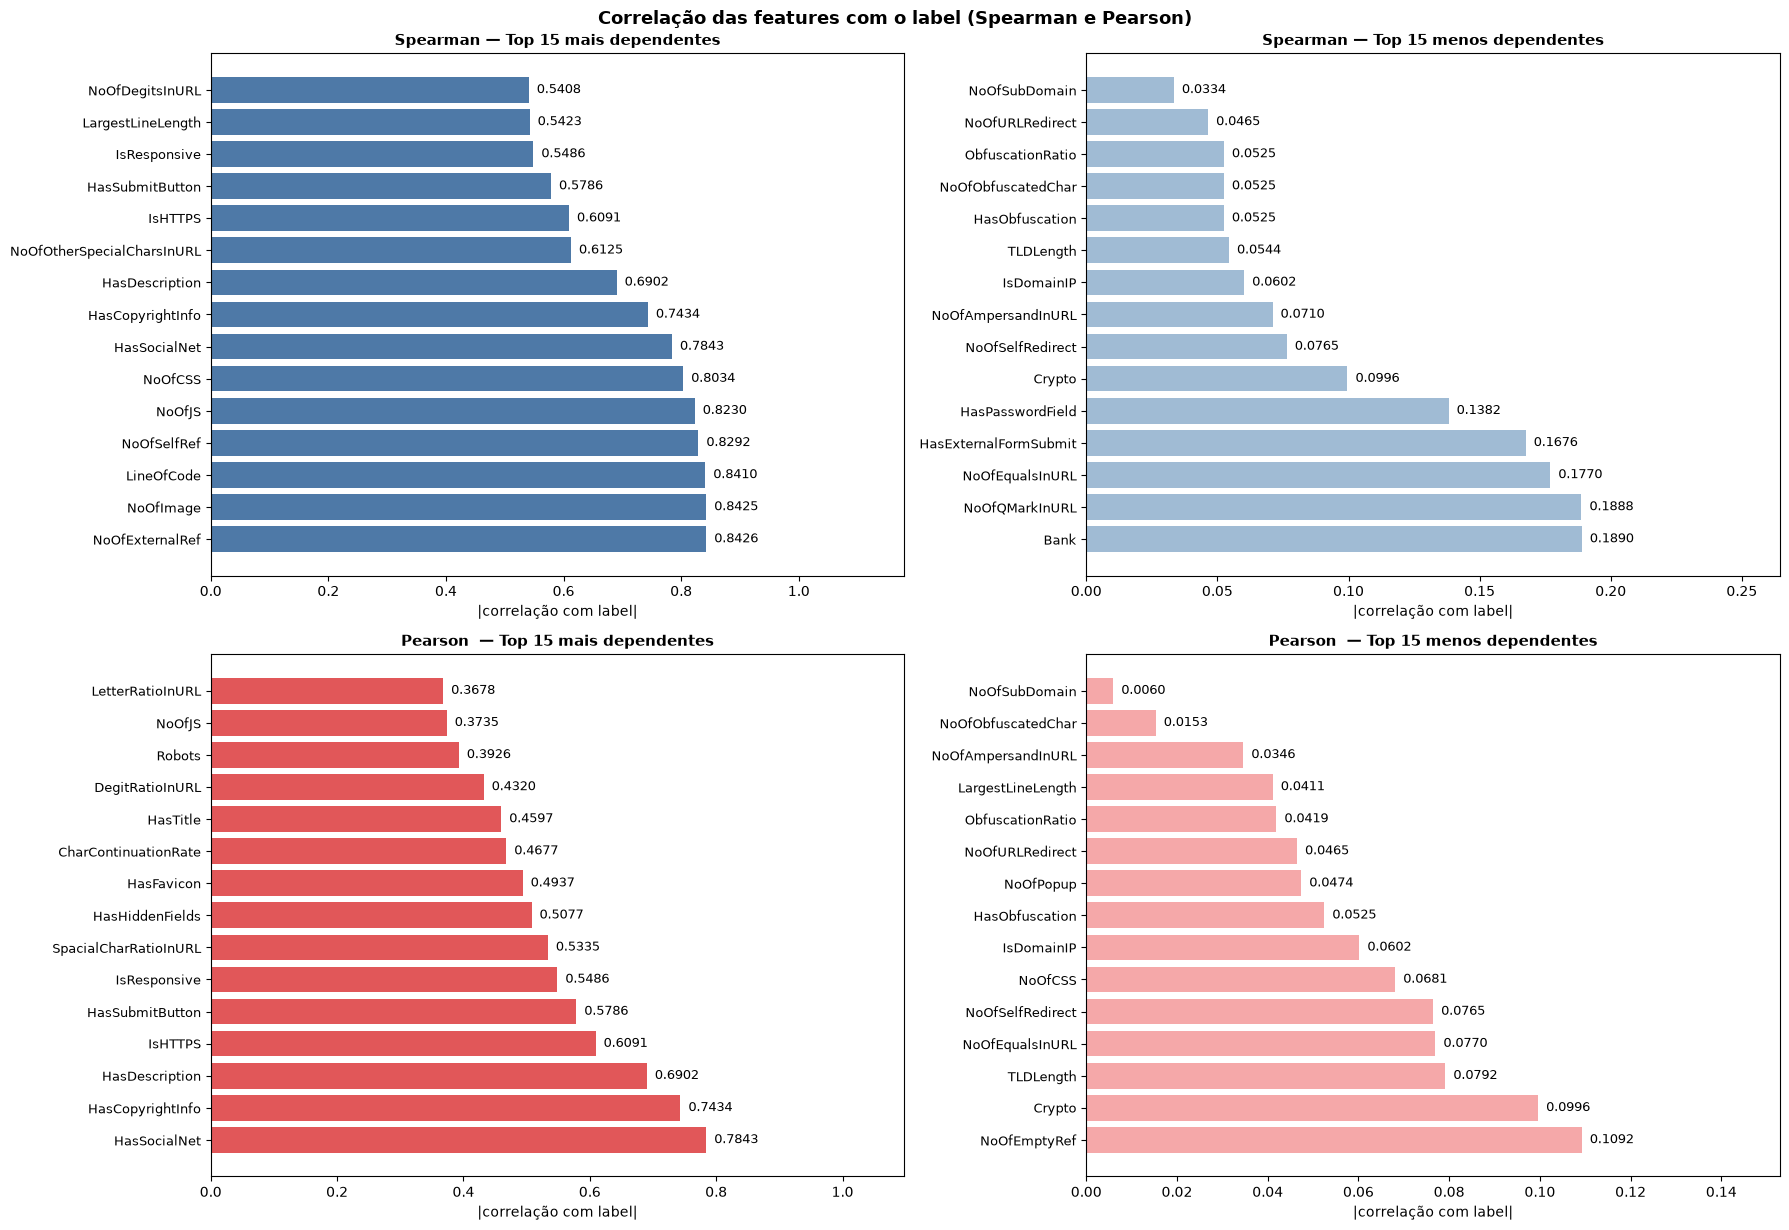


=============================================  SPEARMAN  =============================================
             --- TOP 15 MAIS ---                                      --- TOP 15 MENOS ---
  NoOfExternalRef                     0.8426    NoOfSubDomain                       0.0334
  NoOfImage                           0.8425    NoOfURLRedirect                     0.0465
  LineOfCode                          0.8410    ObfuscationRatio                    0.0525
  NoOfSelfRef                         0.8292    NoOfObfuscatedChar                  0.0525
  NoOfJS                              0.8230    HasObfuscation                      0.0525
  NoOfCSS                             0.8034    TLDLength                           0.0544
  HasSocialNet                        0.7843    IsDomainIP                          0.0602
  HasCopyrightInfo                    0.7434    NoOfAmpersandInURL                  0.0710
  HasDescription                      0.6902    NoOfSelfRedirect             

In [8]:
y_num = y.astype(float)
spear = X.corrwith(y_num, method="spearman").abs().fillna(0)
pears = X.corrwith(y_num, method="pearson").abs().fillna(0)

TOP_N = 15
fig, axes = plt.subplots(2, 2, figsize=(18, TOP_N * 0.7 + 2))

configs = [
    (axes[0, 0], spear, "Spearman — Top 15 mais dependentes",   "#4E79A7", False),
    (axes[0, 1], spear, "Spearman — Top 15 menos dependentes",  "#A0BBD4", True),
    (axes[1, 0], pears, "Pearson  — Top 15 mais dependentes",   "#E15759", False),
    (axes[1, 1], pears, "Pearson  — Top 15 menos dependentes",  "#F5A8A9", True),
]

for ax, serie, titulo, cor, ascendente in configs:
    top = serie.sort_values(ascending=ascendente).head(TOP_N)
    if ascendente:
        top = top.sort_values(ascending=False)  # exibe do menor para maior no gráfico
    ax.barh(range(len(top)), top.values, color=cor)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=9)
    for i, v in enumerate(top.values):
        ax.text(v, i, f"  {v:.4f}", va="center", fontsize=9)
    lim = top.values.max() * 1.4 if top.values.max() > 0 else 0.1
    ax.set_xlim(0, lim)
    ax.set_title(titulo, weight="bold", fontsize=11)
    ax.set_xlabel("|correlação com label|")

plt.suptitle("Correlação das features com o label (Spearman e Pearson)",
             fontsize=13, weight="bold")
plt.tight_layout(); plt.show()

for nome, serie in [("SPEARMAN", spear), ("PEARSON", pears)]:
    s = serie.sort_values(ascending=False)
    print(f"\n{'='*45}  {nome}  {'='*45}")
    print(f"{'--- TOP 15 MAIS ---':^45}{'--- TOP 15 MENOS ---':>45}")
    mais  = s.head(TOP_N).round(4)
    menos = s.tail(TOP_N).sort_values().round(4)
    for (i1, v1), (i2, v2) in zip(mais.items(), menos.items()):
        print(f"  {i1:<35} {v1:.4f}    {i2:<35} {v2:.4f}")

In [9]:
df = df.drop(columns='NoOfObfuscatedChar', errors='ignore')
df.to_csv('df_2_red_1.csv', index=False)
print("colunas shape2: ",df.shape)

rem = [
    "NoOfSubDomain",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfURLRedirect",
    "HasObfuscation",
    "IsDomainIP",
    "TLDLength",
    "NoOfAmpersandInURL",
    "NoOfSelfRedirect",
    "Crypto",
    "NoOfEqualsInURL",
]
df = df.drop(columns=rem, errors='ignore')
df.to_csv('df_3_red_2.csv', index=False)
print("colunas shape3: ",df.shape)


colunas shape2:  (235795, 45)
colunas shape3:  (235795, 35)


In [10]:
'''
y   = df_final['label']
num = df_final.drop(columns=['label']).select_dtypes('number')
continuas = [c for c in num.columns if num[c].nunique() > 15]

def ranking_outliers(classe):
    sub = num[y == classe]
    linhas = []
    for c in continuas:
        s = sub[c]
        p995 = s.quantile(0.995)
        mx   = s.max()
        sev  = (mx / p995) if p995 and p995 > 0 else np.nan   # quão longe o pior ponto vai
        linhas.append({
            'feature': c,
            'p99.5': s.quantile(0.99),
            'max': mx,
            'n_acima_p99.5': int((s > p995).sum()),
            'severidade': sev,        # max / p99.5
        })
    return pd.DataFrame(linhas).sort_values('severidade', ascending=False)

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
print(f"Tamanhos: phishing(0)={int((y==0).sum())}  |  legítimo(1)={int((y==1).sum())}\n")

print("="*72)
print("RANKING — outliers dentro da classe PHISHING (label 0)")
print("="*72)
print(ranking_outliers(0).to_string(index=False))

print("\n" + "="*72)
print("RANKING — outliers dentro da classe LEGÍTIMO (label 1)")
print("="*72)
print(ranking_outliers(1).to_string(index=False))'''

'\ny   = df_final[\'label\']\nnum = df_final.drop(columns=[\'label\']).select_dtypes(\'number\')\ncontinuas = [c for c in num.columns if num[c].nunique() > 15]\n\ndef ranking_outliers(classe):\n    sub = num[y == classe]\n    linhas = []\n    for c in continuas:\n        s = sub[c]\n        p995 = s.quantile(0.995)\n        mx   = s.max()\n        sev  = (mx / p995) if p995 and p995 > 0 else np.nan   # quão longe o pior ponto vai\n        linhas.append({\n            \'feature\': c,\n            \'p99.5\': s.quantile(0.99),\n            \'max\': mx,\n            \'n_acima_p99.5\': int((s > p995).sum()),\n            \'severidade\': sev,        # max / p99.5\n        })\n    return pd.DataFrame(linhas).sort_values(\'severidade\', ascending=False)\n\npd.set_option(\'display.float_format\', lambda v: f\'{v:,.2f}\')\nprint(f"Tamanhos: phishing(0)={int((y==0).sum())}  |  legítimo(1)={int((y==1).sum())}\n")\n\nprint("="*72)\nprint("RANKING — outliers dentro da classe PHISHING (label 0)")\npr

Não houve necessidade de remoção de outliers, uma vez que boa elas estão concentradas em uma unica classe da label. Sendo importante para o algoritmo que será usado.

In [11]:
'''
# dados e cores
y = df_final['label']                      
COR = {0: '#F4A6A6', 1: '#A6C8F4'}
NOME = {0: 'Phi', 1: 'Leg'}

def darken(h, f=0.6):                    
    h = h.lstrip('#'); r, g, b = [int(h[i:i+2], 16) for i in (0, 2, 4)]
    return (r*f/255, g*f/255, b*f/255)

cont = y.value_counts().sort_index()
vals = cont.values
labs = [NOME[i] for i in cont.index]
cols = [COR[i] for i in cont.index]

fig, ax = plt.subplots(figsize=(8, 7))
squash = 0.55                             
tr = Affine2D().scale(1, squash) + ax.transData

total = vals.sum(); start = 90
angles = [start]
for v in vals:
    angles.append(angles[-1] - v/total*360)
depth, layers = 0.30, 30
for L in range(layers, 0, -1):
    dz = depth * L / layers
    for j in range(len(vals)):
        ax.add_patch(Wedge((0, -dz), 1, angles[j+1], angles[j],
                           facecolor=darken(cols[j]), edgecolor='none', transform=tr))
for j in range(len(vals)):
    ax.add_patch(Wedge((0, 0), 1, angles[j+1], angles[j],
                       facecolor=cols[j], edgecolor='white', lw=2, transform=tr))

for j in range(len(vals)):
    mid = np.radians((angles[j] + angles[j+1]) / 2)
    x, z = 0.6*np.cos(mid), 0.6*np.sin(mid)*squash
    ax.text(x, z, f"{labs[j]}\n{vals[j]/total*100:.1f}%\n({vals[j]:,})",
            ha='center', va='center', fontsize=12, weight='bold', color='white')

ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.4, 1.1)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title("prop das classes", weight='bold')
plt.tight_layout(); plt.show()'''

'\n# dados e cores\ny = df_final[\'label\']                      \nCOR = {0: \'#F4A6A6\', 1: \'#A6C8F4\'}\nNOME = {0: \'Phi\', 1: \'Leg\'}\n\ndef darken(h, f=0.6):                    \n    h = h.lstrip(\'#\'); r, g, b = [int(h[i:i+2], 16) for i in (0, 2, 4)]\n    return (r*f/255, g*f/255, b*f/255)\n\ncont = y.value_counts().sort_index()\nvals = cont.values\nlabs = [NOME[i] for i in cont.index]\ncols = [COR[i] for i in cont.index]\n\nfig, ax = plt.subplots(figsize=(8, 7))\nsquash = 0.55                             \ntr = Affine2D().scale(1, squash) + ax.transData\n\ntotal = vals.sum(); start = 90\nangles = [start]\nfor v in vals:\n    angles.append(angles[-1] - v/total*360)\ndepth, layers = 0.30, 30\nfor L in range(layers, 0, -1):\n    dz = depth * L / layers\n    for j in range(len(vals)):\n        ax.add_patch(Wedge((0, -dz), 1, angles[j+1], angles[j],\n                           facecolor=darken(cols[j]), edgecolor=\'none\', transform=tr))\nfor j in range(len(vals)):\n    ax.add_patc

In [12]:
df1 = pd.read_csv('df_1_posprocessamento.csv')
print(df1.shape)
print(df1.columns)


(235795, 46)
Index(['URLLength', 'DomainLength', 'IsDomainIP', 'CharContinuationRate', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL',
       'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'HasFavicon', 'Robots', 'IsResponsive',
       'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields',
       'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label'],
      dtype='str')


In [13]:
df2 = pd.read_csv('df_2_red_1.csv')
print(df2.shape)
print(df2.columns)


(235795, 45)
Index(['URLLength', 'DomainLength', 'IsDomainIP', 'CharContinuationRate', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'ObfuscationRatio', 'NoOfLettersInURL',
       'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect',
       'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay',
       'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label'],
      dtype='str')


In [14]:
df3 = pd.read_csv('df_3_red_2.csv')
print(df3.shape)
print(df3.columns)

(235795, 35)
Index(['URLLength', 'DomainLength', 'CharContinuationRate', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfQMarkInURL',
       'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'HasFavicon', 'Robots', 'IsResponsive',
       'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label'],
      dtype='str')
